# Análise Exploratória do Conjunto de Dados: Breast Cancer Wisconsin (Diagnostic)

Neste notebook, exploraremos os dados do conjunto **"Breast Cancer Wisconsin (Diagnostic) Data Set"**, disponível no [Kaggle](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data).  
Realizaremos uma análise exploratória para entender as características das variáveis e obter insights iniciais sobre o dataset.

---

## 📊 Visão Geral do Dataset

O **Breast Cancer Wisconsin (Diagnostic) Dataset** provém do *UCI Machine Learning Repository* e está disponível no Kaggle com o título _"breast-cancer-wisconsin-data"_.  

É amplamente utilizado em disciplinas de Ciência de Dados e *Machine Learning* como um exemplo clássico de tarefa de **classificação binária** — diagnóstico de câncer de mama **benigno (B)** ou **maligno (M)**.

---

## 🔢 Informações sobre os Atributos

1. **ID number**  
2. **Diagnosis** (M = Malignant, B = Benign)  
3–32. **Características computadas para cada núcleo celular:**

As seguintes 10 características de valor real são avaliadas para cada núcleo:

- **a)** `radius`: média das distâncias do centro aos pontos do perímetro  
- **b)** `texture`: desvio padrão dos valores da escala de cinza  
- **c)** `perimeter`  
- **d)** `area`  
- **e)** `smoothness`: variação local nos comprimentos dos raios  
- **f)** `compactness`: (perimeter² / area - 1.0)  
- **g)** `concavity`: gravidade das porções côncavas do contorno  
- **h)** `concave points`: número de porções côncavas do contorno  
- **i)** `symmetry`  
- **j)** `fractal dimension`: "coastline approximation" - 1  

---

## 📐 Estrutura das Variáveis

Para cada uma das 10 características acima, foram calculadas 3 métricas estatísticas:

- **Mean** (média)  
- **SE** (erro padrão)  
- **Worst** (maior valor entre os três maiores valores registrados)

Isso resulta em **30 atributos numéricos**, por exemplo:

- Campo 3: `mean radius`  
- Campo 13: `radius SE`  
- Campo 23: `worst radius`  

---

## ℹ️ Outras Informações Relevantes

- Todos os valores foram normalizados com **quatro dígitos significativos**  
- **Não há valores ausentes (missing values)**  
- **Distribuição das classes:**
  - **357** casos benignos (B)
  - **212** casos malignos (M)

---


## Análise exploratória dos dados

In [1]:
# Importando bibliotecas utilizadas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score

In [2]:
# Carregando a planilha com o dataset
dados = pd.read_csv('../data/breast-cancer-wisconsin-data.csv') 
# visualizando cabeçalho e parte dos dados originais
dados.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 🧹 Remoção de Colunas Irrelevantes

Com base na documentação do dataset e na análise preliminar do cabeçalho, identificamos que as colunas `id` e `Unnamed: 32` **não possuem relevância analítica** para o nosso objetivo.

Essas colunas não apresentam **correlação com a variável-alvo `diagnosis`** (diagnóstico de tumor maligno ou benigno) e, portanto, serão removidas para:

- Eliminar ruído nos dados  
- Reduzir o risco de overfitting  
- Otimizar a performance dos modelos  
- Melhorar a interpretabilidade das análises

A limpeza de dados é uma etapa essencial para garantir resultados consistentes e confiáveis ao longo do processo analítico.

In [3]:
# Removendo colunas desnecessárias/irrevelevantes para o estudo
dados.drop(columns=['id', 'Unnamed: 32'], inplace=True)
dados.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 🔄 Conversão da Coluna `diagnosis`

A coluna `diagnosis` representa o diagnóstico do tumor e é uma **variável categórica**.  
Para facilitar a análise e aplicação de modelos de machine learning, realizamos a seguinte conversão para valores numéricos:

- 🟥 **Maligno (`'M'`)** → **1**
- 🟩 **Benigno (`'B'`)** → **0**

In [4]:
# Transformar a variável categória "diagnosis" em um valor numérico
dados['diagnosis'] = dados['diagnosis'].map({'M': 1, 'B': 0})
dados.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
## Descrevendo os dados para uma análise geral dos valores presentes
dados.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [6]:
colunas_remover = [col for col in dados.columns if any(x in col for x in ['worst', 'se'])]
dados_filtrado = dados.drop(columns=colunas_remover)
dados_filtrado.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883


## 🔍 Correlação entre as Variáveis e a Coluna-Alvo `diagnosis`

A seleção de variáveis com alta correlação com a variável-alvo `diagnosis` é uma etapa essencial na construção de modelos preditivos.  
Essa análise permite identificar quais atributos possuem relação estatística significativa com o diagnóstico (benigno ou maligno), ajudando a:

- Reduzir a dimensionalidade do dataset  
- Eliminar variáveis irrelevantes ou redundantes  
- Melhorar a performance e a generalização do modelo  

A seguir, será calculada a matriz de correlação entre as variáveis do dataset, com foco na identificação dos atributos mais correlacionados com `diagnosis`.

In [7]:
# Correlacao entre as variaveis com relacao ao alvo diagnosis
corr_com_diagnosis = dados_filtrado.corr()['diagnosis'].abs().sort_values(ascending=False)
print(corr_com_diagnosis)

diagnosis                 1.000000
concave points_mean       0.776614
perimeter_mean            0.742636
radius_mean               0.730029
area_mean                 0.708984
concavity_mean            0.696360
compactness_mean          0.596534
texture_mean              0.415185
smoothness_mean           0.358560
symmetry_mean             0.330499
fractal_dimension_mean    0.012838
Name: diagnosis, dtype: float64


In [ ]:
# Renomeando colunas que possuem espaço no nome substituindo o espaço por underline "_"
dados = dados.rename({"concave points_mean":"concave_points_mean"})
# dados = dados.rename({"concave points_worst":"concave_points_worst"})
dados.head()

In [8]:
# Selecionar as variáveis com correlação absoluta maior que 0.7 (inclusive a própria coluna diagnosis)
maior_corr_com_diagnosis = corr_com_diagnosis[corr_com_diagnosis > 0.7].index.tolist()
# cortar a tabela original selecionando apenas as colunas com corr > 0.7
df_cut = dados[maior_corr_com_diagnosis]
df_cut.head()

,diagnosis,concave points_mean,perimeter_mean,radius_mean,area_mean
0,1,0.14710,122.80,17.99,1001.0
1,1,0.07017,132.90,20.57,1326.0
2,1,0.12790,130.00,19.69,1203.0
3,1,0.10520,77.58,11.42,386.1
4,1,0.10430,135.10,20.29,1297.0


In [ ]:
df_cut = df_cut.rename({"concave points_mean":"concave_points_mean"})
# df_cut = df_cut.rename({"concave points_worst":"concave_points_worst"})
print (df_cut)
#sns.set_theme(style="whitegrid", palette="muted")

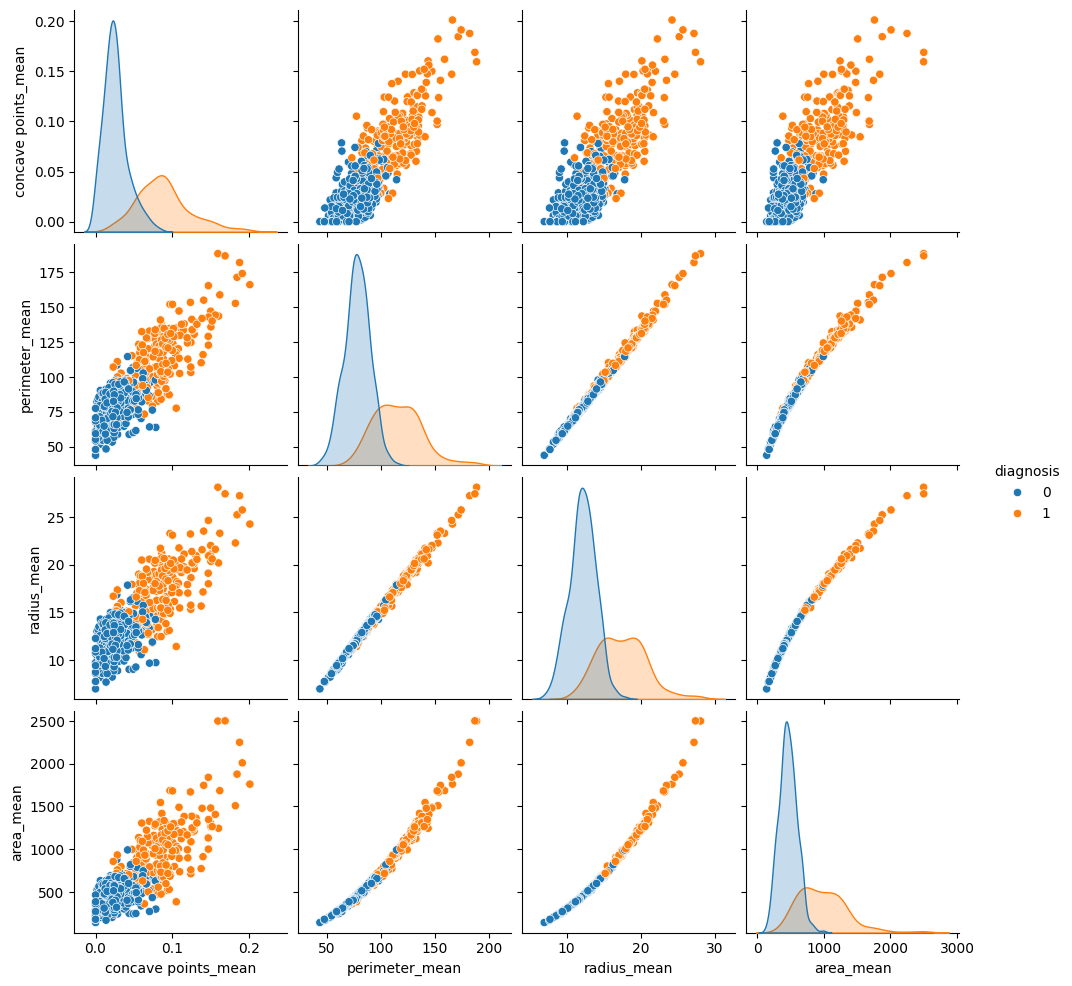

In [9]:
# Vamos analisar a correção entre as variáveis com correlação absoluta maior que 0.7 e diagnosis
maior_corr_com_diagnosis.remove('diagnosis')
sns.pairplot(df_cut, vars=maior_corr_com_diagnosis, hue="diagnosis")


<Axes: >

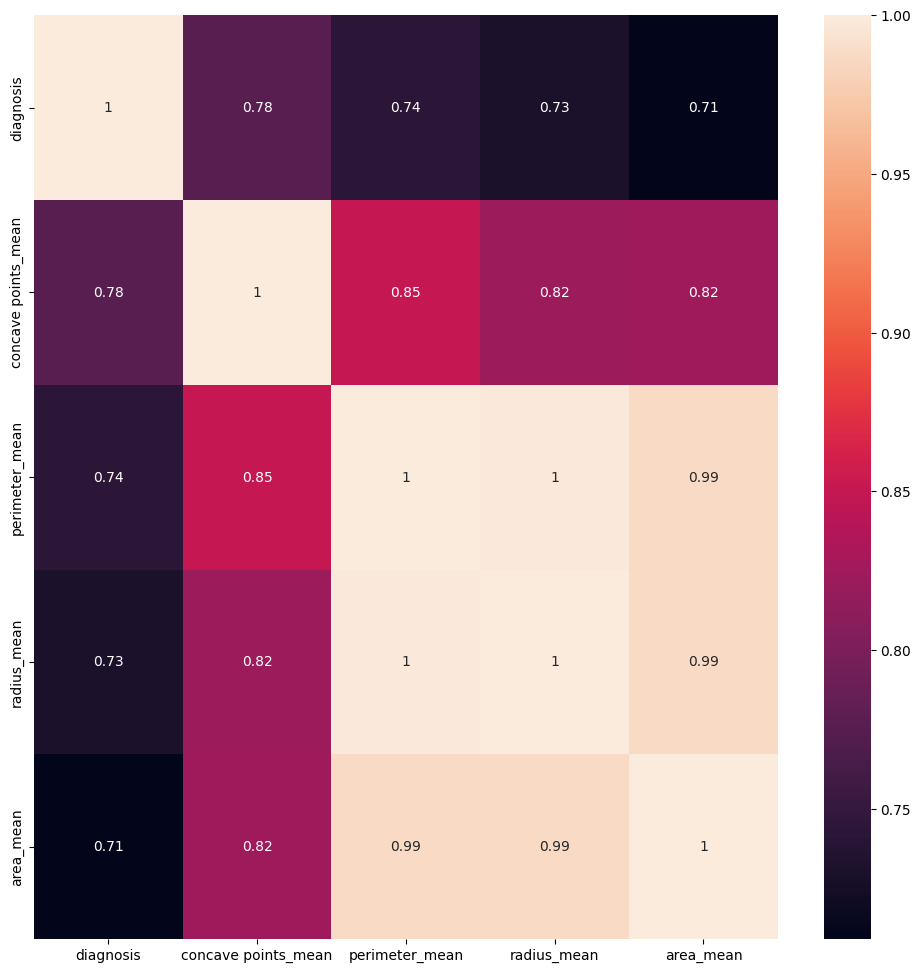

In [10]:
correlation = df_cut.corr()
fig, ax = plt.subplots(figsize=(12,12)) 
sns.heatmap(correlation, annot=True,  ax=ax)

In [ ]:
dados.groupby('diagnosis').describe()

##  🎯 Modelagem, Treinamento e Avaliação

A seguir serão realizadas as seguintes etapas:

- Separação dos dados de treinamento e testes
- Treinamento: KNN e Regressão Logística
- Avaliação dos modelos

Avaliação dos Modelos
Para prever o diagnóstico de Câncer, foram utilizados dois modelos diferentes. Cada modelo foi avaliado utilizando as seguintes métricas:

- Acurácia
- Recall
- F1-score

MODELO 1: KNN – K Vizinhos Mais Próximos (com normalização)
Classifica os clientes com base na distância dos vizinhos mais próximos.
Requer normalização, pois é altamente sensível à escala das variáveis.
Simples e intuitivo, mas pode ter performance inferior com dados desbalanceados.
Apresentou métricas medianas e sinal de underfitting.

MODELO 2: Refressão Logística (com normalização)
-Modelo linear, indicado para Clasificação binária.
Requer normalização dos dados, pois é sensivel à escala das variáveis.
Facil de interpretar e útil para identificar variaveis relevantes.
Serviu como modelo base e apresentou o melhor desempenho geral nas métricas

Alguns dos algoritmos comumente usados incluem Regressão Logística (LR), XGBoost (XGB), aumento de gradiente (GB), árvores de decisão (DTs), Árvores Extras, Floresta Aleatória (RF) e máquina de aumento de gradiente de luz (LGBM) (Ahamed et al., [ 5 ], p. 1).

https://www.sciencedirect.com/science/article/pii/S2666521224000607#bib5

In [26]:
#Dividindo os dados em variáveis independentes (X) e dependentes (y)
# Variáveis independentes são as características dos tumores
# Variável dependente é o diagnóstico (M ou B)

x = dados[['radius_mean', 'perimeter_mean', 'area_mean','concave points_mean']]

y = dados['diagnosis']

# TODO VER COMO SEPARAR DADOS DE VALIDAÇÃO
#Separação dos dados de treinamento e testes
X_train, X_test, y_train, y_test = train_test_split(   
    dados.drop('diagnosis', axis=1),
    dados['diagnosis'],
    test_size=0.2,
    random_state=42
)

In [27]:
#Treinamento do Modelo KNN
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

# Previsões com o modelo KNN
y_pred_knn = knn_model.predict(X_test)

In [28]:
# Exibindo as previsões do modelo
print("Previsões do modelo KNN:")
print(y_pred_knn)

# Avaliando o modelo KNN
print("Métricas de Avaliação do Modelo KNN:")
print("Acurácia:", accuracy_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))


Previsões do modelo KNN:
[1 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0
 0 0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 1 0 0 1 0 0 1
 0 0 1]
Métricas de Avaliação do Modelo KNN:
Acurácia: 0.9298245614035088
Recall: 0.8837209302325582
F1 Score: 0.9047619047619048


In [29]:
#Treinamento do modelo Regressão Logística
r_log_model = LogisticRegression(max_iter=2800)
r_log_model.fit(X_train, y_train)

# Previsões com o modelo de Regressão Logística
y_pred_r_log = r_log_model.predict(X_test)

In [30]:
# Exibindo as previsões do modelo
print("Previsões do modelo de Regressão Logística:")
print(y_pred_r_log)

# Avaliando o modelo Regressão Logística
print("Métricas de Avaliação do Modelo Regressão Logística:")
print("Acurácia:", accuracy_score(y_test, y_pred_r_log))
print("Recall:", recall_score(y_test, y_pred_r_log))
print("F1 Score:", f1_score(y_test, y_pred_r_log))


Previsões do modelo de Regressão Logística:
[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 1 1]
Métricas de Avaliação do Modelo Regressão Logística:
Acurácia: 0.956140350877193
Recall: 0.9069767441860465
F1 Score: 0.9397590361445783


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Comparação de modelos utilizados
# Função para gerar métricas + matriz de confusão como string
def gerar_metricas(nome, y_test_metr, y_pred):
    return {
        'Modelo': nome,
        'Acurácia': accuracy_score(y_test_metr, y_pred),
        'Recall': recall_score(y_test_metr, y_pred),
        'Precisão': precision_score(y_test_metr, y_pred),
        'F1-Score': f1_score(y_test_metr, y_pred),
    }

# Coletar métricas de todos os modelos
resultados = [
    gerar_metricas("Regressão Logística", y_test, y_pred_r_log),
    gerar_metricas("KNN", y_test, y_pred_knn),
]

# Criar DataFrame
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by='F1-Score', ascending=False)

# Exibir a tabela
print("📊 COMPARATIVO DE MODELOS")
print("-" * 26)
display(df_resultados.round(4))

📊 COMPARATIVO DE MODELOS
--------------------------


,Modelo,Acurácia,Recall,Precisão,F1-Score
0,Regressão Logística,0.9561,0.9070,0.9750,0.9398
1,KNN,0.9298,0.8837,0.9268,0.9048


Resultados e interpretação dos dados
Para prever o diagnóstico de Câncer, foram utilizados dois modelos diferentes e cada modelo foi avaliado utilizando as seguintes métricas:

Acurácia
Recall
F1-score

MODELO 1: KNN – K Vizinhos Mais Próximos (com normalização)
Classifica os clientes com base na distância dos vizinhos mais próximos.
Requer normalização, pois é altamente sensível à escala das variáveis.
Simples e intuitivo, mas pode ter performance inferior com dados desbalanceados.
Apresentou métricas medianas e sinal de underfitting.

MODELO 2: Refressão Logística (com normalização)
Modelo linear, indicado para Clasificação binária.
Requer normalização dos dados, pois é sensivel à escala das variáveis.
Facil de interpretar e útil para identificar variaveis relevantes.
Serviu como modelo base e apresentou o melhor desempenho geral nas métricas


CONCLUSÃO : Melhor Modelo é Regressão Logística
Após aplicar e comparar os dois modelos (KNN e Regressão Logística), considerando as métricas de desempenho (Acurácia, Recall e F1-Score), conclui-se:

Regressão Logística apresentou o melhor desempenho geral:
Maior acurácia (0.95) e** F1-Score (0.93)**.

Bom equilibrio entre precisão (0.97) e recall (0.90).

Modelo simples, interpretável e eficiente, ideal para começar.

KNN apresentou desempenho inferior, com menor F1-Score

# Resultados e Interpretação dos Dados

Para prever o diagnóstico de Câncer, foram utilizados dois modelos diferentes.  
Cada modelo foi avaliado utilizando as seguintes métricas:

- **Acurácia**
- **Recall**
- **F1-score**

---

## 📊 Modelo 1: KNN – K Vizinhos Mais Próximos (com normalização)
- Classifica os diagnósticos com base na distância dos vizinhos mais próximos.  
- **Requer normalização**, pois é altamente sensível à escala das variáveis.  
- Simples e intuitivo, mas pode ter performance inferior com dados desbalanceados.  
- Apresentou métricas **medianas** e sinal de **underfitting**.  

---

## 📊 Modelo 2: Regressão Logística (com normalização)
- Modelo linear, indicado para **classificação binária**.  
- **Requer normalização** dos dados, pois é sensível à escala das variáveis.  
- Fácil de interpretar e útil para identificar variáveis relevantes.  
- Serviu como **modelo base** e apresentou o **melhor desempenho**
